In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [160]:
Level_df1 = pd.read_csv('Level_VIX_TermSpread_2-10Spread_VXN.csv', index_col = ['Date'], parse_dates=True)
Level_df2 = pd.read_csv('Level_BKK_CFNAI_EquityVol_StLSI.csv', index_col = ['Date'], parse_dates=True)
Quarterly_df = pd.read_csv('Quarterly_Rate_Housing_IndProd_Inflation_PPI_GDP.csv', index_col = ['Date'], parse_dates=True, date_format='%Y%Q')
First_Diff_df = pd.read_csv('First_Diff_UMich_UnemploymentRate.csv', index_col=['Date'], parse_dates=True)
MOVE_CESIUSD = pd.read_csv('MOVE_CESIUSD.csv', index_col=['Date'], parse_dates=True)
GPU = pd.read_csv('Geopolitical Risk 1985-2025.csv', index_col=['month'], parse_dates=True)
GEP = pd.read_csv('Global Economic Policy Uncertainty Data.csv', index_col = ['Date'], parse_dates = True)
NewOrders = pd.read_csv('New Orders.csv', index_col = [0], parse_dates=True)


## Compiling a Monthly Dataframe

In [186]:
# GEP, GPU, New Orders
Risk = GPU['2004-12-01':].iloc[:,0]
Uncertainty = GEP['2004-12-01':].iloc[:,0]

#Add in New Orders, UMich and Unemployment Rate
Risk_Uncertainty_New_Orders = pd.concat([Risk, Uncertainty, NewOrders], axis = 1)
Risk_Uncertainty_New_Orders = (Risk_Uncertainty_New_Orders.diff() / Risk_Uncertainty_New_Orders) * 100
Risk_Uncertainty_New_Orders = pd.concat([Risk_Uncertainty_New_Orders, First_Diff_df], axis = 1)
Risk_Uncertainty_New_Orders = Risk_Uncertainty_New_Orders.dropna(how = 'all')
Risk_Uncertainty_New_Orders.to_csv('PercentDifferenced_Risk_Uncertainty_New_Orders_UMich_Unemployment.csv')

In [131]:
# Combine CESIUSD and Move
Level_df1 = MOVE_CESIUSD.merge(Level_df1, how='outer', left_index=True, right_index=True).dropna(how = 'all')
Level_df1 = Level_df1.loc['2005':'2025-05-10'].copy()

# Get Level Data in Month Frequency
Level_df1_M = Level_df1.resample('M').last()

# Reindex to Monthly Frequency
Level_df1_M.index = Level_df1_M.index.to_period('M').start_time

#Combine DataFrames then save
Level_Monthly = pd.concat([Level_df1_M, Level_df2], axis=1)
Level_Monthly.to_csv('Level_Monthly.csv')

C:\Users\Phillip\AppData\Local\Temp\ipykernel_24520\679768490.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Level_df1_M = Level_df1.resample('M').last()


In [197]:
''' 
Combining everything into MONTHLY Dataframe

'''

Level_Monthly = pd.read_csv('Level_Monthly.csv',index_col = [0], parse_dates=True)

Differenced_df = pd.read_csv('PercentDifferenced_Risk_Uncertainty_New_Orders_UMich_Unemployment.csv', index_col = [0], parse_dates=True)

Monthly = Differenced_df.merge(Level_Monthly, how = 'outer',
                               left_index = True, right_index = True
                               ).dropna(how='all'
                                        ).drop(columns = ['.CESIUSD_x', '.MOVE_x', '.CESIUSD_y', '.MOVE_y']
                                               ).rename(columns={'.CESIUSD': 'Citi Suprise', 
                                                         '.MOVE' : 'MOVE',
                                                         'CFNAI': 'National Activity Index'})

Monthly.to_csv('Monthly.csv')

## Compiling Quarterly DataFrame - Finish

In [ ]:
# Sample Monthly Level Data to Quarterly
First_Diff_df_Q = First_Diff_df.resample('Q').last()
Level_df2_Q = Level_df2.resample('Q').last()
Level_df1_Q = Level_df1.resample('Q').last()

# Sample Monthly Indices to Quarterly Freq
Level_df1_Q.index = Level_df1_Q.index.to_period('Q')
Level_df2_Q.index = Level_df2_Q.index.to_period('Q')

# Reindex to Quarterly 
First_Diff_df_Q = First_Diff_df_Q.reindex(Quarterly_df.index)
Level_df1_Q = Level_df1_Q.reindex(Quarterly_df.index)
Level_df2_Q = Level_df2_Q.reindex(Quarterly_df.index)

#Combine DataFrames then save
Level_Quarterly = pd.concat([Level_df1_Q, Level_df2_Q], axis = 1)
# Level_Quarterly.to_csv('Level_Quarterly.csv')

In [179]:
Quarterly_df_First_diff_df = Quarterly_df.merge(First_Diff_df_Q, left_index= True, right_index= True, how = 'outer')
All_df = pd.concat([Quarterly_df_First_diff_df, Level_df1_Q, Level_df2_Q], axis=1)
All_df.head()

,Housing Start,Industrial Production Index,Core Inflation,PPI,GDP,UMich Sentiment,Unemployment Rate,VIX,VXN NASDAQ,2-10 Spread,Term Spread,High Yield Spread,BKK Leading Index,CFNAI,Equity Vol Measure,St Louis Stress Index
Date,,,,,,,,,,,,,,,,
2005Q1,23.462,5.693,-0.040,4.137,7.889,NaN,NaN,14.02,17.65,0.70,1.71,3.52,-1.058583,-0.15,0.28851,-0.86265
2005Q2,-3.869,2.268,-3.097,6.648,4.957,NaN,NaN,12.04,14.46,0.28,0.81,3.85,-0.808874,0.44,0.36583,-0.72670
2005Q3,9.833,-1.688,6.207,11.229,6.985,NaN,NaN,11.92,13.31,0.16,0.79,3.54,-1.231763,-0.85,0.28744,-0.80108
2005Q4,-5.836,3.702,20.643,14.880,5.641,NaN,NaN,12.07,14.26,-0.02,0.31,3.65,-0.584304,0.42,0.27980,-0.70980
2006Q1,10.371,3.853,18.157,-3.681,8.513,NaN,NaN,11.39,16.31,0.04,0.23,3.13,-0.673391,0.37,0.13958,-1.03836


## Preprocessing (Simple Imputer) Monthly Data

In [207]:
Monthly = Monthly.ffill().loc['2005-02':]

# PCA

In [200]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

## PCA on Monthly Data

We can see it takes almost 8 PCs to explain 80% of the variance. This shows our indicators chosen are capturing a lot of variance. 

We can use different numbers of PCs to identify which indices capture all PCs the best

In [224]:
n_components = 6
scaler = StandardScaler()
X_scaled = scaler.fit_transform(Monthly)
PCA_ = PCA(n_components=n_components)
X_PCA = PCA_.fit_transform(X_scaled)
X_PCA = pd.DataFrame(X_PCA, columns=[f'PC{i+1}' for i in range(n_components)])


In [215]:
print(' Explained Variance :', PCA_.explained_variance_)
print(' Explained Variance Ratio :', PCA_.explained_variance_ratio_)

 Explained Variance : [4.83143137 2.22648503 1.98312056 1.40502689 1.04232807 0.98477704
 0.90627887 0.84078983 0.60278305 0.48627133]
 Explained Variance Ratio : [0.3007269  0.13858501 0.12343706 0.08745429 0.06487851 0.06129632
 0.05641029 0.052334   0.03751954 0.0302674 ]


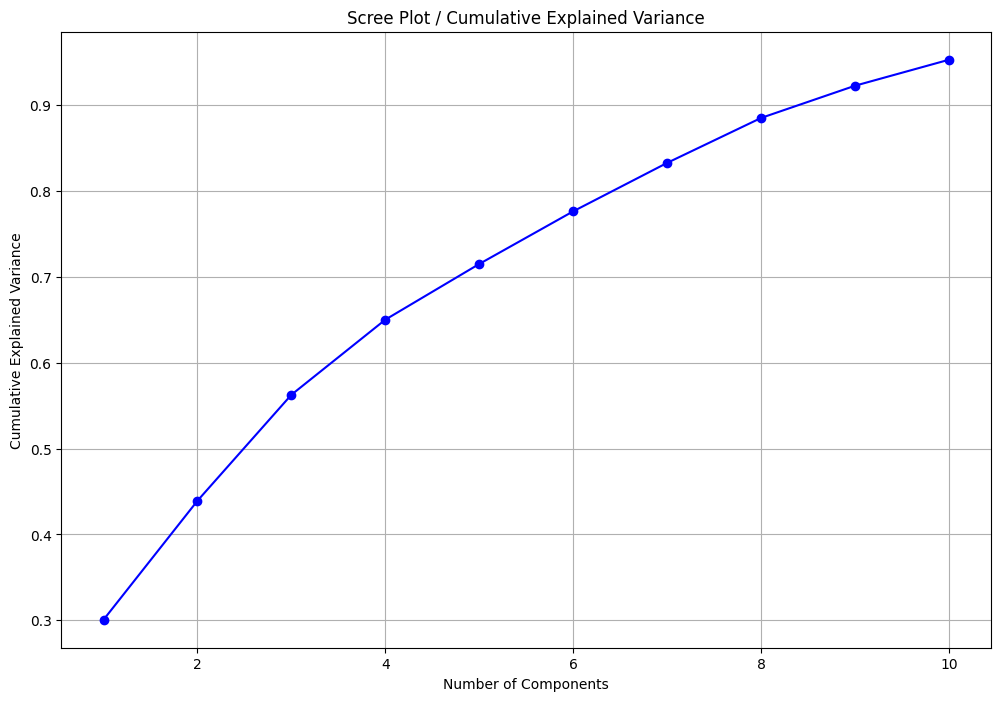

In [216]:
plt.figure(figsize = (12, 8))
plt.plot(
    range(1, len(PCA_.explained_variance_ratio_) + 1),
    np.cumsum(PCA_.explained_variance_ratio_),
    'bo-'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot / Cumulative Explained Variance')
plt.grid(True)
plt.show()

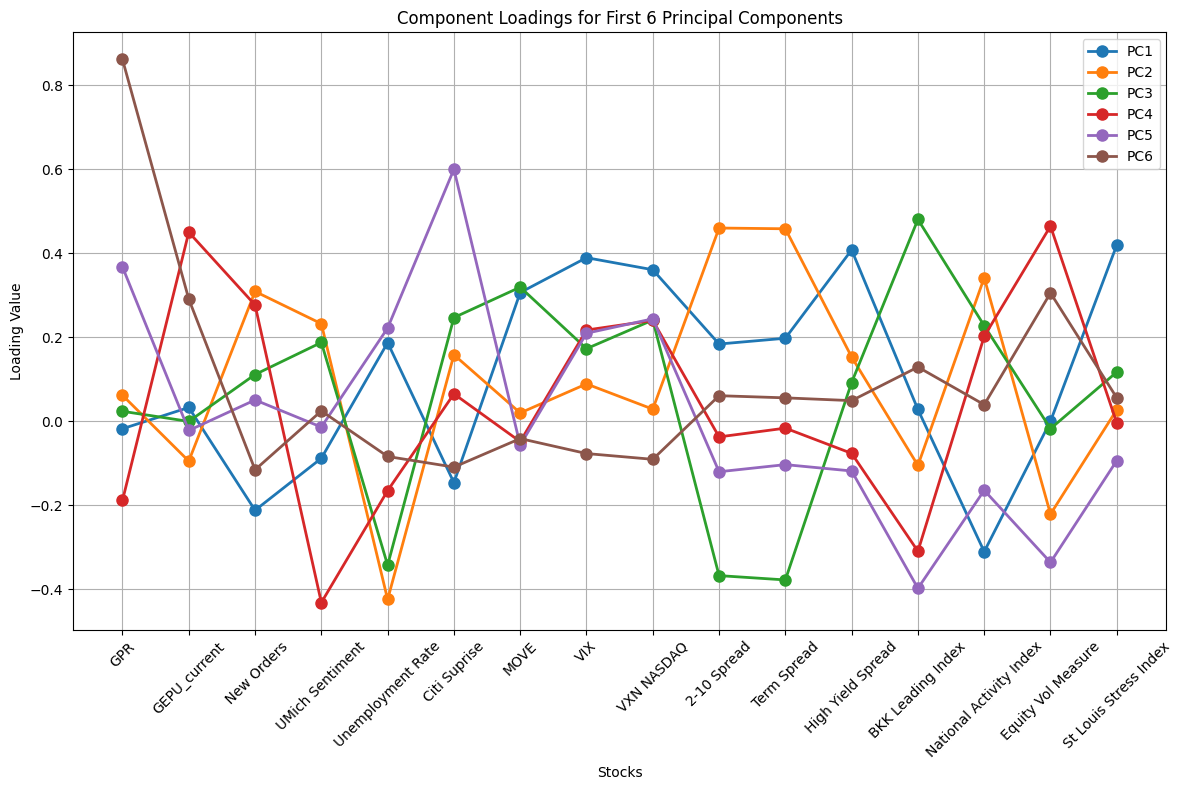

Top contributors to each principal component:


In [ ]:
#Change number of PCs to plot

# Get component loadings
loadings = pd.DataFrame(
    PCA_.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=Monthly.columns
)

# Plot loadings for first n PCs on a single plot
plt.figure(figsize=(12, 8))
for i in range(n_components):
    plt.plot(loadings.index, loadings[f'PC{i+1}'], 
             marker='o', 
             linewidth=2, 
             markersize=8,
             label=f'PC{i+1}')

plt.title(f'Component Loadings for First {n_components} Principal Components')
plt.xlabel('Stocks')
plt.ylabel('Loading Value')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [229]:
Contributor_Score = {}


# Print top contributors for each PC
print("Top contributors to each principal component:")


for i in range(n_components):
    print(f"\nPC{i+1} (variance explained : {PCA_.explained_variance_ratio_[i].round(2)}):")
    top_contributors = loadings[f'PC{i+1}'].abs().sort_values(ascending=False).head(5)
    for stock, loading in top_contributors.items():
        print(f"{stock}: {loading:.3f}")
        if stock not in Contributor_Score.keys():
            Contributor_Score[stock] = loading * PCA_.explained_variance_ratio_[i]
        else:
            Contributor_Score[stock] = Contributor_Score[stock] + loading * PCA_.explained_variance_ratio_[i]
            


Top contributors to each principal component:

PC1 (variance explained : 0.3):
St Louis Stress Index: 0.420
High Yield Spread: 0.408
VIX: 0.390
VXN NASDAQ: 0.361
National Activity Index: 0.310

PC2 (variance explained : 0.14):
2-10 Spread: 0.460
Term Spread: 0.459
Unemployment Rate: 0.424
National Activity Index: 0.342
 New Orders: 0.309

PC3 (variance explained : 0.12):
BKK Leading Index: 0.481
Term Spread: 0.377
2-10 Spread: 0.367
Unemployment Rate: 0.342
MOVE: 0.320

PC4 (variance explained : 0.09):
Equity Vol Measure: 0.465
GEPU_current: 0.450
UMich Sentiment: 0.431
BKK Leading Index: 0.309
 New Orders: 0.277

PC5 (variance explained : 0.06):
Citi Suprise: 0.600
BKK Leading Index: 0.397
GPR: 0.368
Equity Vol Measure: 0.335
VXN NASDAQ: 0.244

PC6 (variance explained : 0.06):
GPR: 0.862
Equity Vol Measure: 0.306
GEPU_current: 0.291
BKK Leading Index: 0.130
 New Orders: 0.115


In [228]:
sorted(Contributor_Score.items(), key=lambda x : -x[1])

[('National Activity Index', np.float64(0.1406117949017147)),
 ('St Louis Stress Index', np.float64(0.12631009729552595)),
 ('VXN NASDAQ', np.float64(0.12445948179738975)),
 ('High Yield Spread', np.float64(0.12280987837544001)),
 ('BKK Leading Index', np.float64(0.12009129259374865)),
 ('VIX', np.float64(0.11723965536269171)),
 ('Term Spread', np.float64(0.1101302847817553)),
 ('2-10 Spread', np.float64(0.1091103042128081)),
 ('Unemployment Rate', np.float64(0.10094740723136955)),
 ('Equity Vol Measure', np.float64(0.08118261597806095)),
 ('GPR', np.float64(0.07667039208048468)),
 (' New Orders', np.float64(0.07417025690551131)),
 ('GEPU_current', np.float64(0.05725248483550922)),
 ('MOVE', np.float64(0.039458975363405695)),
 ('Citi Suprise', np.float64(0.03895112758473733)),
 ('UMich Sentiment', np.float64(0.03770452403576023))]